# 05 — Customer Segmentation (RetentionIQ, M2)

Owner: Kimberly (M2 — CLV / segmentation / experimental design)

Segments the Miracle customer base on RFM + behavioural features so the rest of
the product (recommender, demo) can act per segment, not per individual.

**Pipeline:** `feature_table.parquet` → log-transform skewed features → standardize
→ pick *k* by silhouette → KMeans → profile and name clusters → save params.

The saved `segmentation_kmeans.json` (scaler + centroids + names) is what
`score_customers.py` uses to tag every customer with a segment, so the segment
shows up live in the demo. Assignment at scoring time is pure numpy (no sklearn
dependency), and we verify it matches sklearn exactly at the end.

> Note on this base: roughly 88% of Miracle customers are one-time buyers, so
> expect one large low-frequency cluster. That is a real finding about the
> business, not a clustering bug.

In [15]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA = ROOT / "data"

df = pd.read_parquet(DATA / "features" / "feature_table.parquet")
print(f"{len(df):,} customers loaded")
df.head()

751,956 customers loaded


,customer_id,frequency,recency,t,days_since_last_order,monetary_value,avg_order_value,total_orders,total_revenue,avg_days_between_orders,std_days_between_orders,refund_count,total_refund_amount,refund_rate,first_order_date,last_order_date,is_churned
0,43d49e501840d6909e34db122d651acb,420,804,804,0,116.82,116.82,421,49181.28,1.0,0.1,0,0.0,0.0,2024-01-01 17:01:23,2026-03-15 01:17:31,0
1,d29cb3376e670e5201dbb7a17f1073cd,80,762,803,41,270.56,270.56,81,21915.43,19.5,28.1,0,0.0,0.0,2024-01-02 22:27:01,2026-02-02 11:19:46,0
2,612feec0473dcb46b40e499d63f31584,187,749,803,54,88.28,88.28,188,16595.83,5.3,5.2,0,0.0,0.0,2024-01-02 18:30:00,2026-01-20 09:11:46,0
3,3af1f5a4d635314aaf0ed5fa51b8280a,3,200,640,440,1787.97,1787.97,4,7151.86,66.7,45.3,0,0.0,0.0,2024-06-13 03:05:46,2024-12-30 13:39:24,1
4,e13501520f1754ef39a8575d454fd33c,3,16,788,772,1590.78,1590.78,4,6363.11,8.0,1.4,0,0.0,0.0,2024-01-17 03:30:21,2024-02-02 06:19:52,1


## 1. Feature selection

We cluster on the classic RFM signals plus two behavioural ones:

- **Recency** — `days_since_last_order`
- **Frequency** — `total_orders`
- **Monetary** — `total_revenue` (log1p, right-skewed)
- **Basket size** — `avg_order_value` (log1p)
- **Dissatisfaction** — `refund_rate`

Monetary and basket size are heavily right-skewed, so we `log1p` them before
scaling. Then standardize so KMeans (a distance method) treats each feature
on the same scale.

In [16]:
FEATS = ["days_since_last_order", "total_orders", "total_revenue", "avg_order_value", "refund_rate"]
LOG   = {"total_revenue", "avg_order_value", "total_orders"}

X = df[FEATS].copy()
for c in LOG:
    X[c] = np.log1p(X[c].clip(lower=0))

scaler = StandardScaler().fit(X)
Xs = scaler.transform(X)
print("feature matrix:", Xs.shape)
print("heads-up: customers with > 50 orders (likely wholesale / heavy subscription):", int((df["total_orders"] > 50).sum()))

feature matrix: (751956, 5)
heads-up: customers with > 50 orders (likely wholesale / heavy subscription): 3


## 2. Choose *k* by silhouette

We scan k = 2..7 and pick the k with the best average silhouette (how cleanly
separated the clusters are). We also plot inertia (the elbow) for context.

silhouette by k: {2: 0.356, 3: 0.301, 4: 0.352, 5: 0.387, 6: 0.42, 7: 0.42}
best k = 6


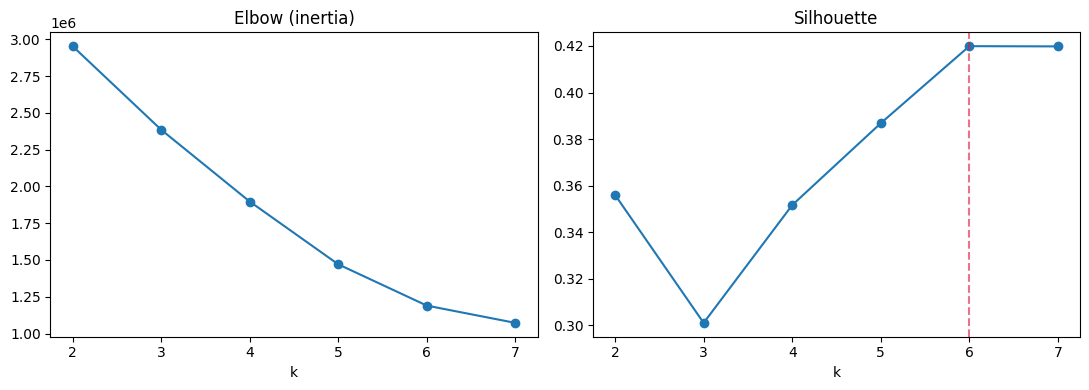

In [17]:
sil, inertia = {}, {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xs)
    inertia[k] = km.inertia_
    sil[k] = silhouette_score(Xs, km.labels_, sample_size=min(5000, len(Xs)), random_state=42)

best_k = max(sil, key=sil.get)
print("silhouette by k:", {k: round(v, 3) for k, v in sil.items()})
print("best k =", best_k)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(list(inertia), list(inertia.values()), "o-"); ax[0].set_title("Elbow (inertia)"); ax[0].set_xlabel("k")
ax[1].plot(list(sil), list(sil.values()), "o-"); ax[1].set_title("Silhouette"); ax[1].set_xlabel("k")
ax[1].axvline(best_k, color="crimson", ls="--", alpha=.6)
plt.tight_layout(); plt.show()

## 3. Fit KMeans and profile the clusters

Profiles are shown in original units (not standardized) so they are readable.

In [18]:
km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(Xs)
df["segment_id"] = km.labels_

profile = (df.groupby("segment_id")
             .agg(customers=("customer_id", "size"),
                  recency_days=("days_since_last_order", "mean"),
                  orders=("total_orders", "mean"),
                  revenue=("total_revenue", "mean"),
                  aov=("avg_order_value", "mean"),
                  refund_rate=("refund_rate", "mean"))
             .round(2))
profile["share"] = (profile["customers"] / len(df) * 100).round(1).astype(str) + "%"
profile

,customers,recency_days,orders,revenue,aov,refund_rate,share
segment_id,,,,,,,
0,106917,312.75,1.00,321.17,320.96,0.00,14.2%
1,41656,356.19,1.05,234.51,224.48,1.15,5.5%
2,20837,444.12,1.22,31.87,27.27,0.02,2.8%
3,223919,572.19,1.01,146.76,146.31,0.00,29.8%
4,85715,279.57,2.46,426.35,180.71,0.06,11.4%
5,272912,176.52,1.00,153.85,153.81,0.00,36.3%


## 4. Name the segments

We name clusters from an RFM composite (recent + frequent + high-spend = best).
These names are heuristic starting points — rename to match how the brand talks
about its customers. The names get saved and flow straight into the demo.

In [19]:
z = lambda s: (s - s.mean()) / (s.std() + 1e-9)
composite = (-z(profile["recency_days"]) + z(profile["orders"]) + z(profile["revenue"]))
ranked = composite.sort_values(ascending=False).index.tolist()

NAME_LADDER = ["Champions", "Loyal", "Promising", "Needs attention", "At risk", "Hibernating", "Lost"]
segment_names = {cid: (NAME_LADDER[i] if i < len(NAME_LADDER) else f"Segment {cid}")
                 for i, cid in enumerate(ranked)}

# overrides so names match the PROFILE, not just the composite rank:
# a very high-refund cluster is a returns problem; an extreme-orders cluster is wholesale / heavy subscription.
ref_hi = max(profile["refund_rate"].mean() + profile["refund_rate"].std(), 0.15)
ord_hi = profile["orders"].mean() + 2 * profile["orders"].std()
for cid in profile.index:
    if profile.loc[cid, "refund_rate"] >= ref_hi:
        segment_names[cid] = "High returns"
    elif profile.loc[cid, "orders"] >= ord_hi:
        segment_names[cid] = "Power buyers"

df["segment"] = df["segment_id"].map(segment_names)
for cid in ranked:
    print(f"  cluster {cid} -> {segment_names[cid]:16s} ({profile.loc[cid,'share']} of base)")

  cluster 4 -> Power buyers     (11.4% of base)
  cluster 0 -> Loyal            (14.2% of base)
  cluster 5 -> Promising        (36.3% of base)
  cluster 1 -> High returns     (5.5% of base)
  cluster 2 -> At risk          (2.8% of base)
  cluster 3 -> Hibernating      (29.8% of base)


## 5. Visualize

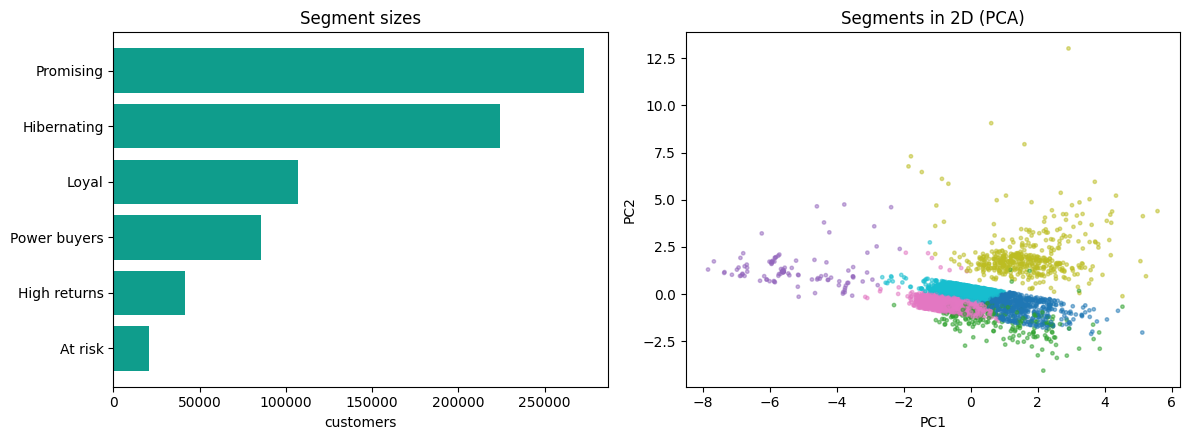

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# cluster sizes
sizes = df["segment"].value_counts()
ax[0].barh(sizes.index[::-1], sizes.values[::-1], color="#0F9D8C")
ax[0].set_title("Segment sizes"); ax[0].set_xlabel("customers")

# PCA 2D scatter (sample for speed)
samp = df.sample(min(4000, len(df)), random_state=42)
pcs = PCA(n_components=2, random_state=42).fit_transform(scaler.transform(
    samp[FEATS].assign(**{c: np.log1p(samp[c].clip(lower=0)) for c in LOG})))
sc = ax[1].scatter(pcs[:, 0], pcs[:, 1], c=samp["segment_id"], cmap="tab10", s=6, alpha=.5)
ax[1].set_title("Segments in 2D (PCA)"); ax[1].set_xlabel("PC1"); ax[1].set_ylabel("PC2")
plt.tight_layout(); plt.show()

## 6. Save for scoring + verify numpy parity

We save the scaler, centroids and names. `score_customers.py` reproduces the
assignment with numpy only (standardize, nearest centroid). We confirm that
numpy assignment matches sklearn exactly before trusting it downstream.

In [21]:
payload = {
    "features": FEATS,
    "log_features": sorted(LOG),
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "centroids": km.cluster_centers_.tolist(),
    "k": int(best_k),
    "segment_names": {str(k): v for k, v in segment_names.items()},
    "silhouette": round(float(sil[best_k]), 4),
}
(DATA / "models").mkdir(parents=True, exist_ok=True)
json.dump(payload, open(DATA / "models" / "segmentation_kmeans.json", "w"), indent=2)

# per-customer assignment, handy for joins / the eval notebook
(DATA / "scored").mkdir(parents=True, exist_ok=True)
df[["customer_id", "segment_id", "segment"]].to_parquet(DATA / "scored" / "customer_segments.parquet", index=False)
print("saved data/models/segmentation_kmeans.json and data/scored/customer_segments.parquet")

def assign(row, p):
    feats, logset = p["features"], set(p["log_features"])
    x = np.array([np.log1p(max(row[f], 0)) if f in logset else row[f] for f in feats], float)
    xs = (x - np.array(p["scaler_mean"])) / np.array(p["scaler_scale"])
    return int(((np.array(p["centroids"]) - xs) ** 2).sum(1).argmin())

p = json.load(open(DATA / "models" / "segmentation_kmeans.json"))
sample = df.sample(min(500, len(df)), random_state=1)
match = (sample.apply(lambda r: assign(r, p), axis=1).values == sample["segment_id"].values).mean()
print(f"numpy assignment matches sklearn on {len(sample)} rows: {match*100:.0f}%")

saved data/models/segmentation_kmeans.json and data/scored/customer_segments.parquet
numpy assignment matches sklearn on 500 rows: 100%


## Takeaways

- Segments are saved and flow into the demo through `score_customers.py` (each
  at-risk customer shows its segment).
- Expect one large low-frequency / one-time segment — that is the 88% one-time
  buyer reality, and it doubles as the product's positioning angle (turning
  one-timers into repeats is the headline opportunity).
- Silhouette on this base is modest (overlapping behaviour is normal for DTC),
  so treat segments as **actionable groupings**, not hard natural classes.

**Next:** `06_evaluation.ipynb` checks model quality (churn honesty, CLV sanity,
segment separation).